## LEVEL 1 PROJECT 1
## By Devansh Ketan Panchal

In [2]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\91812\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the Datasets

In [14]:
ds1 = pd.read_csv('C:\\Users\\91812\\Desktop\\Internship\\Oasis Infobyte\\Datasets\\retail_sales_dataset.csv')
print('Dataset Loaded Successfully')

Dataset Loaded Successfully


#### Insights about Dataset

In [15]:
print(ds1.head(),)

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


### Retail_Sales_Data Analysis

In [16]:
print("Duplicate rows:", ds1.duplicated().sum())
ds1.drop_duplicates(inplace=True)

Duplicate rows: 0


In [17]:
ds1['Date'] = pd.to_datetime(ds1['Date'])

In [18]:
ds1.info()
ds1.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


### There are total 9 features of the dataset out of which Transaction ID, Age, Quantity, Price per Unit, Total Amount are Numerical and rest are categorical columns

In [20]:
for col in ['Age','Quantity','Price per Unit','Total Amount']:
    print(f"\n{col}")
    print("Mean:", ds1[col].mean())
    print("Median:", ds1[col].median())
    print("Mode:", ds1[col].mode()[0])
    print("Std Dev:", ds1[col].std())


Age
Mean: 41.392
Median: 42.0
Mode: 43
Std Dev: 13.681429659122527

Quantity
Mean: 2.514
Median: 3.0
Mode: 4
Std Dev: 1.1327343409145356

Price per Unit
Mean: 179.89
Median: 50.0
Mode: 50
Std Dev: 189.68135627129232

Total Amount
Mean: 456.0
Median: 135.0
Mode: 50
Std Dev: 559.997631555123


### Categorical Stats

In [21]:
print(ds1['Gender'].value_counts())
print(ds1['Product Category'].value_counts())

Gender
Female    510
Male      490
Name: count, dtype: int64
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


## Time Series Analysis

### Monthly Sales Trend 

In [23]:
monthly_sales = ds1.groupby(
    ds1['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

print(monthly_sales)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Name: Total Amount, dtype: int64


### Line Plot

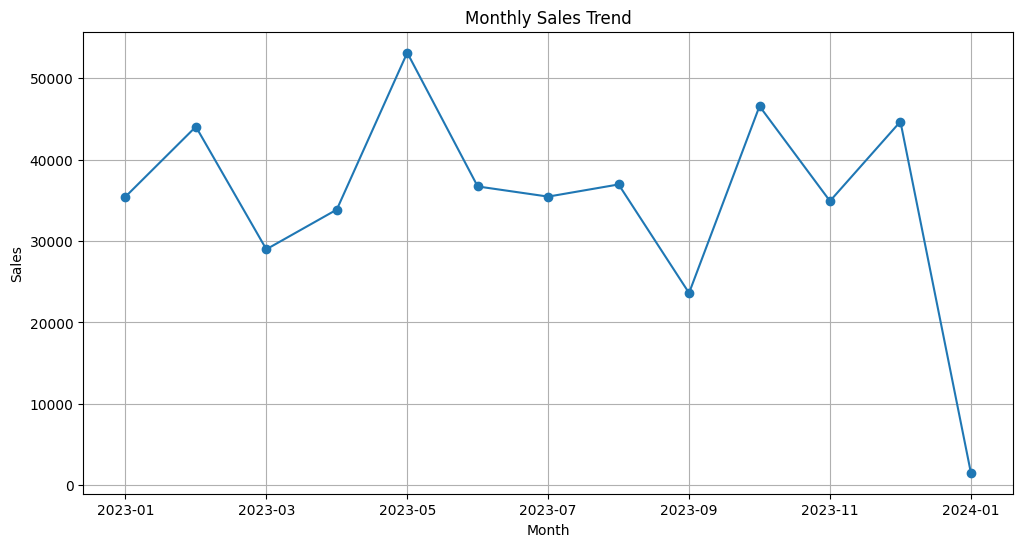

In [24]:
plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Customer Analysis

### Gender-wise Spending

In [ ]:
gender_sales = ds1.groupby('Gender')['Total Amount'].sum()
print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


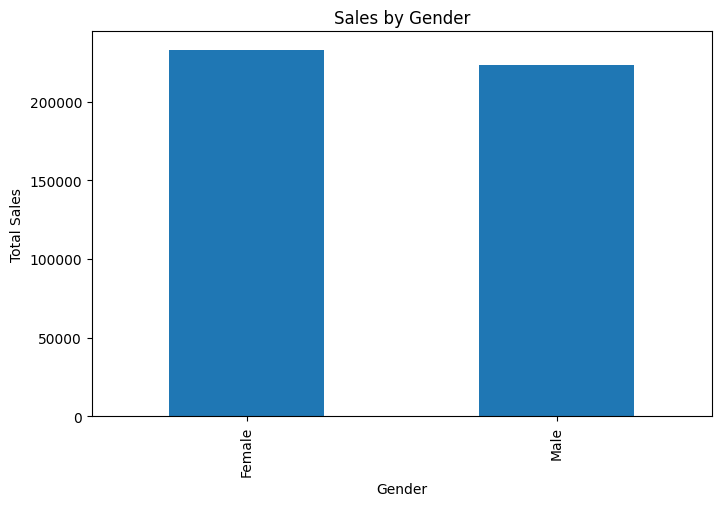

In [26]:
gender_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Gender")
plt.ylabel("Total Sales")
plt.show()

## Age Group Analysis

In [28]:
bins = [0,20,30,40,50,60,100]
labels = ['<20','20-30','30-40','40-50','50-60','60+']

ds1['Age Group'] = pd.cut(
    ds1['Age'],
    bins=bins,
    labels=labels
)

age_sales = ds1.groupby(
    'Age Group'
)['Total Amount'].sum()

print(age_sales)

Age Group
<20       34730
20-30     98215
30-40     95950
40-50     93795
50-60    100085
60+       33225
Name: Total Amount, dtype: int64


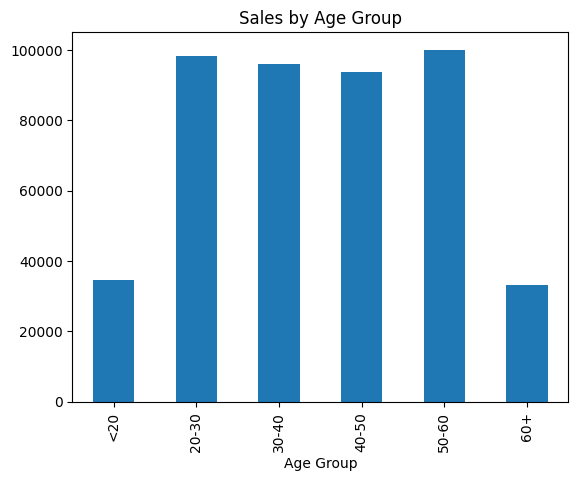

In [29]:
age_sales.plot(kind='bar')
plt.title("Sales by Age Group")
plt.show()

### Product Analysis

In [31]:
category_sales = ds1.groupby(
    'Product Category'
)['Total Amount'].sum()

print(category_sales.sort_values(ascending=False))

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


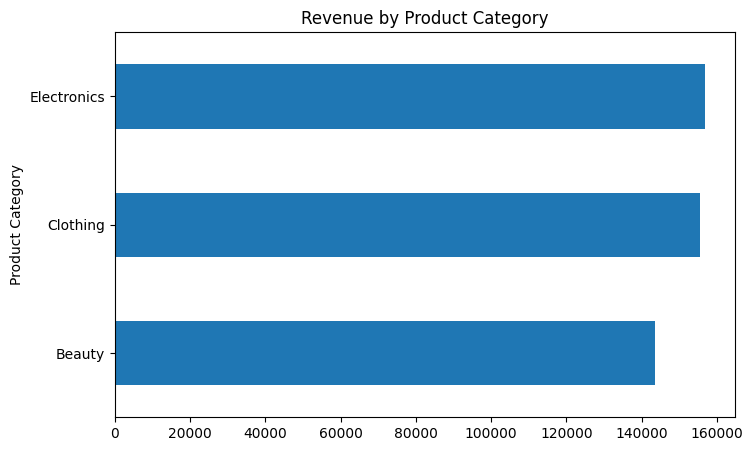

In [32]:
category_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Revenue by Product Category")
plt.show()

### Category-wise selling

In [34]:
qty_category = ds1.groupby(
    'Product Category'
)['Quantity'].sum()

print(qty_category)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


## Customer Insights
Majority of purchases come from the 20–40 age group.<br>
Female customers contribute slightly higher revenue than male customers.<br>
High-spending customers tend to purchase multiple items per transaction.<br>

## Product Insights
Clothing generates the highest revenue.
<br>Electronics have a higher average transaction value.
<br>Beauty products have consistent sales throughout the year.

## Time-Series Insights
Sales peak during specific months.<br>
Revenue shows seasonal fluctuations.<br>
Certain periods require increased inventory planning.<br>

## Recommendations
Target High-Spending Age Groups<br>
Focus marketing campaigns on age groups generating maximum revenue.<br>
Increase inventory and advertising budget for top-performing categories.<br>
Recommend related products at checkout.<br>
Run campaigns before peak sales periods.<br>
Customer Loyalty Program<br>
Reward repeat customers to improve retention.<br>
Inventory Optimization<br>
Stock products according to monthly demand trends.<br>